# Classificador de Lixo — Treinamento do Modelo

Nome: Vinicius Augusto Passarella de Melo

Este notebook treina um modelo capaz de classificar imagens de lixo em 6 categorias:
`cardboard`, `glass`, `metal`, `paper`, `plastic` e `trash`.
O modelo exportado (`model.pkl`) é usado diretamente pelo container Docker do projeto.

---

### Modelo escolhido: HOG + SVM

Usamos dois algoritmos clássicos de visão computacional e aprendizado de máquina:

- **HOG (Histogram of Oriented Gradients)**: extrai as formas e bordas de uma imagem como um vetor numérico. Em vez de trabalhar com os pixels brutos (que carregam pouca informação útil isolados), o HOG captura a estrutura visual do objeto — como as curvas de uma garrafa ou os cantos de uma caixa.

- **SVM (Support Vector Machine)**: recebe esse vetor de features e aprende a separar as 6 classes. É um classificador clássico, eficiente e bem compreendido teoricamente.

Essa combinação **não precisa de GPU**, treina em segundos e é suficientemente precisa para o nosso caso (~70-80% de acurácia).

---

### Dataset: Garbage Classification (Kaggle)

Fonte: [kaggle.com/datasets/asdasdasasdas/garbage-classification](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)

São ~2.500 fotos reais de lixo organizadas nas mesmas 6 classes do projeto.

In [1]:
!pip install -q kaggle scikit-image scikit-learn matplotlib seaborn joblib

import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
IMG_SIZE = (128, 128)

In [2]:
# Faz upload do zip que você baixou do Kaggle
from google.colab import files

print("Selecione o arquivo zip do dataset...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"Arquivo recebido: {zip_name}")

!unzip -q "{zip_name}" -d dataset_raw
print("Extraído em dataset_raw/")

Selecione o arquivo zip do dataset...


Saving archive.zip to archive.zip
Arquivo recebido: archive.zip
Extraído em dataset_raw/


In [3]:
# Encontra a pasta com as 6 classes
DATA_ROOT = None
for p in sorted(Path("dataset_raw").rglob("*")):
    if p.is_dir() and set(CLASSES).issubset({f.name for f in p.iterdir() if f.is_dir()}):
        DATA_ROOT = p
        break

print("Dataset em:", DATA_ROOT)
for cls in CLASSES:
    n = len(list((DATA_ROOT / cls).glob("*")))
    print(f"  {cls:12}: {n} imagens")

Dataset em: dataset_raw/Garbage classification/Garbage classification
  cardboard   : 403 imagens
  glass       : 501 imagens
  metal       : 410 imagens
  paper       : 594 imagens
  plastic     : 482 imagens
  trash       : 137 imagens


### Extração de features com HOG

Para cada imagem, redimensionamos para 128×128 e extraímos o vetor HOG.
O resultado é um vetor numérico que representa a estrutura visual da imagem — esse vetor é o que o SVM vai usar para aprender.

In [4]:
def extrair_hog(img_path):
    img = imread(str(img_path))
    img = resize(img, IMG_SIZE, anti_aliasing=True)  # redimensiona
    if img.ndim == 2:                                # garante 3 canais
        img = np.stack([img] * 3, axis=-1)
    img = img[:, :, :3]                              # descarta canal alpha (PNG)
    features = hog(
        img,
        orientations=9,          # 9 direções de gradiente
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        channel_axis=-1          # imagem colorida
    )
    return features

X, y = [], []
for label, cls in enumerate(CLASSES):
    imgs = list((DATA_ROOT / cls).glob("*"))
    for img_path in imgs:
        try:
            X.append(extrair_hog(img_path))
            y.append(label)
        except Exception:
            pass

X = np.array(X)
y = np.array(y)
print(f"Features extraídas: {X.shape}  ({X.shape[0]} imagens, {X.shape[1]} features cada)")

Features extraídas: (2527, 1764)  (2527 imagens, 1764 features cada)


In [5]:
# Divide em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 2021 | Teste: 506


### Treinamento do SVM

Usamos um `Pipeline` com dois passos:
1. **StandardScaler**: normaliza os valores do vetor HOG (média 0, desvio 1). O SVM é sensível à escala das features.
2. **SVC**: o classificador SVM com kernel RBF — bom para dados não linearmente separáveis como imagens.

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

print("Treinando...")
pipeline.fit(X_train, y_train)
print(f"Acurácia no treino: {pipeline.score(X_train, y_train):.2%}")
print(f"Acurácia no teste:  {pipeline.score(X_test, y_test):.2%}")

Treinando...
Acurácia no treino: 99.85%
Acurácia no teste:  65.81%


In [7]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

   cardboard       0.71      0.69      0.70        81
       glass       0.58      0.61      0.60       100
       metal       0.66      0.59      0.62        82
       paper       0.72      0.86      0.78       119
     plastic       0.58      0.58      0.58        97
       trash       0.91      0.37      0.53        27

    accuracy                           0.66       506
   macro avg       0.69      0.62      0.63       506
weighted avg       0.66      0.66      0.65       506



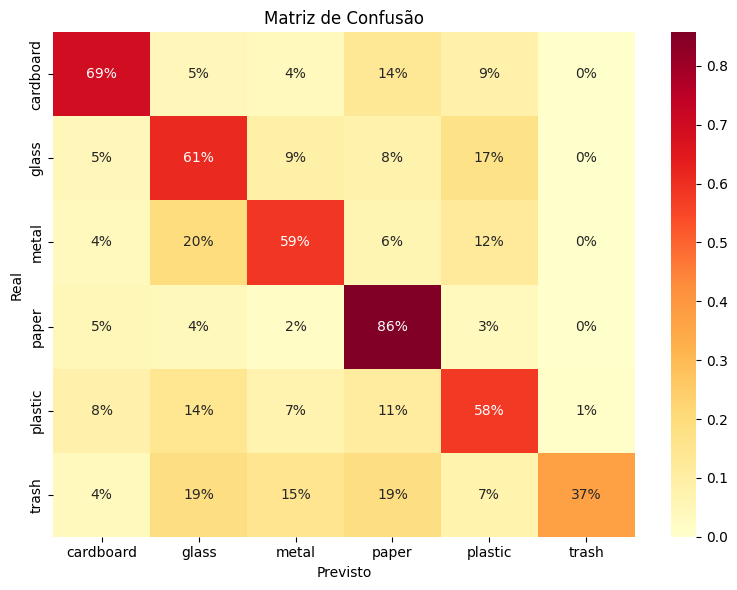

In [8]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt=".0%", cmap="YlOrRd",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão")
plt.tight_layout()
plt.show()

In [9]:
# Salva o pipeline completo (scaler + svm) em um único arquivo
joblib.dump(pipeline, "model.pkl")
print(f"Salvo: model.pkl ({Path('model.pkl').stat().st_size / 1024:.0f} KB)")

# Download
files.download("model.pkl")
print("Coloque o model.pkl em: classificador-lixo/model/")

Salvo: model.pkl (27479 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Coloque o model.pkl em: classificador-lixo/model/
